## Laboratorio 7 — Aprendizaje No Supervisado
### Clustering
#### K-Means


In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import random

# Generar número aleatorio de centros entre 1 y 20
num_centers = random.randint(1, 20)

blob_centers = []
min_distance = 2.5  # Distancia mínima entre centros para visualización clara

while len(blob_centers) < num_centers:
    nuevo_punto = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(nuevo_punto - center) > min_distance
           for center in blob_centers):
        blob_centers.append(nuevo_punto)

blob_centers = np.array(blob_centers)
blob_std = np.full(num_centers, 2.0)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {num_centers} centroides")
print("Coordenadas de los centroides:")
print(blob_centers)


In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)


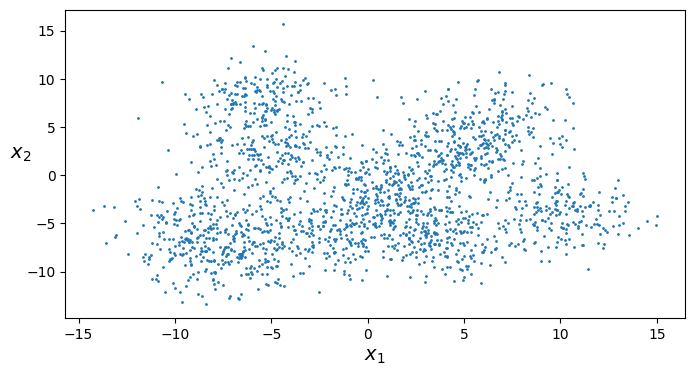

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()


En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.


In [ ]:
from sklearn.cluster import KMeans

k = len(blob_centers)  # Usar el número real de centros generados
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred


array([10, 10,  3, ...,  6,  0, 10], shape=(2000,), dtype=int32)

In [ ]:
kmeans.cluster_centers_

array([[-2.62585031, -6.25848569],
       [-5.40613818,  8.01613798],
       [ 6.33417586,  6.13827192],
       [-7.64236589, -9.16472616],
       [10.25625141, -4.03493853],
       [ 4.07382227, -6.9573523 ],
       [ 1.24271458, -3.18732209],
       [-8.71994583, -4.70040976],
       [-5.47110554,  1.82248026],
       [ 0.34594924,  1.03685958],
       [ 5.4269991 ,  1.60625176]])

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)


array([ 9, 10,  8,  8], dtype=int32)

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)


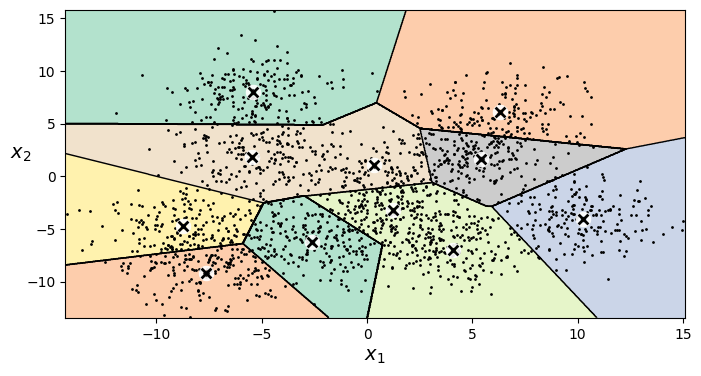

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.


In [ ]:
kmeans.transform(X_new)

array([[ 8.66589151,  8.08827832,  7.5661799 , 13.52985095, 11.90004941,
         9.84023314,  5.33410255, 10.99695168,  5.47398475,  1.0233867 ,
         5.44126427],
       [ 9.99263617, 10.3371696 ,  5.31432245, 15.42436586,  9.4378847 ,
         9.02148849,  5.47689351, 13.50009708,  8.47296538,  2.82340662,
         2.45873185],
       [ 9.26604259,  5.56337498,  9.84761847, 13.02045021, 15.00728362,
        12.21424686,  7.50223844,  9.59239755,  2.737319  ,  3.87934229,
         8.54147809],
       [ 8.76647361,  6.01807936, 10.01817655, 12.55457676, 14.77950009,
        11.81018519,  7.09550981,  9.19585129,  2.56230279,  3.65187023,
         8.47426101]])

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.


In [ ]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)


KMeans(algorithm='elkan', max_iter=3, n_clusters=11, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=11, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=11, n_init=1, random_state=5)


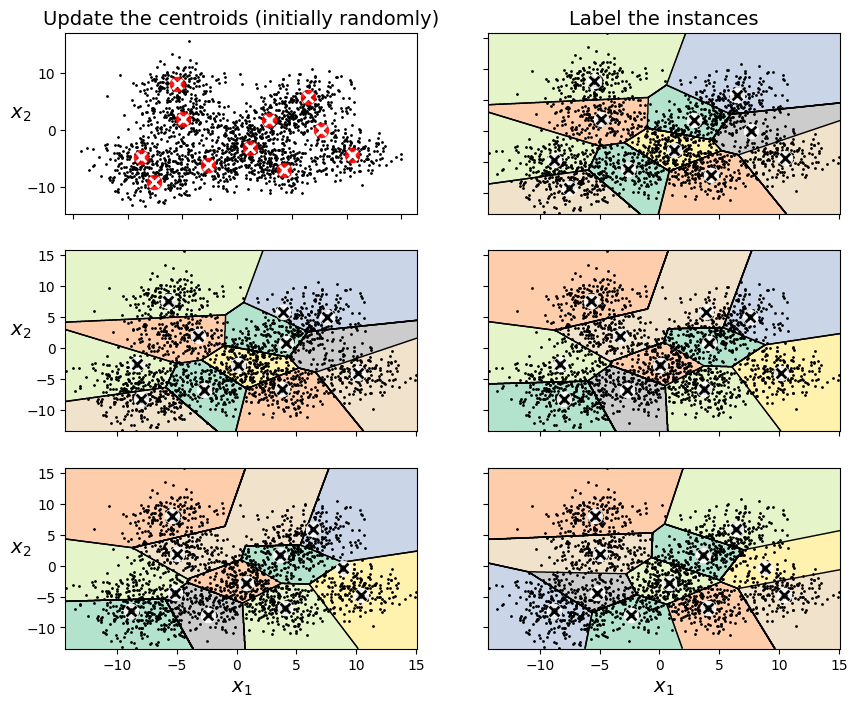

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()


Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.


In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)


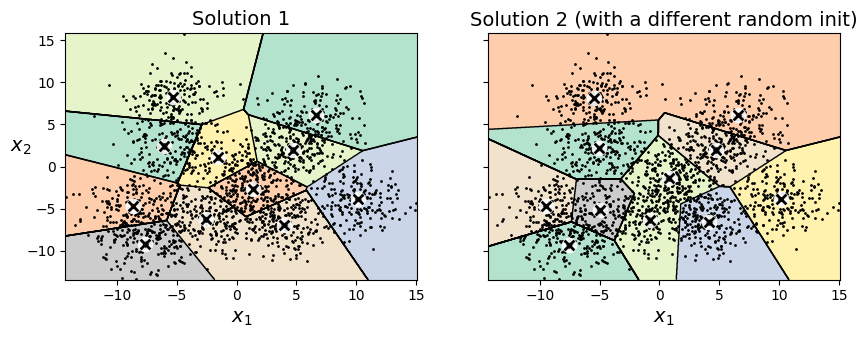

In [ ]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1", "Solution 2 (with a different random init)")
plt.show()


Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en *Scikit-Learn*.


In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)


KMeans(algorithm='elkan', init='random', n_clusters=11, n_init=10,
       random_state=11)


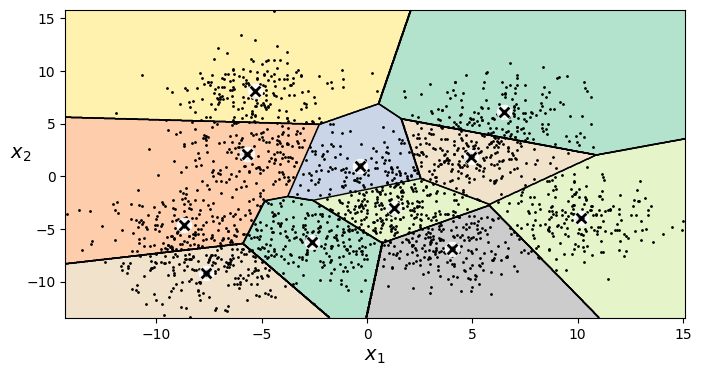

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()


Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas (como la que usa *Scikit-Learn* por defecto) y también está el *mini-batch K-Means*, ideal cuando el conjunto de datos es tan grande que no cabe en memoria.


In [ ]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]


In [ ]:
from sklearn.cluster import MiniBatchKMeans

k_mb = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k_mb, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
            minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans


In [ ]:
best_kmeans.score(X)

-25601.08837127089

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.


### Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir. Cuando no tenemos etiquetas, probamos varios valores y usamos métricas para decidir. Una de las más útiles es el **silhouette score**.


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)


0.3718606906354263

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.


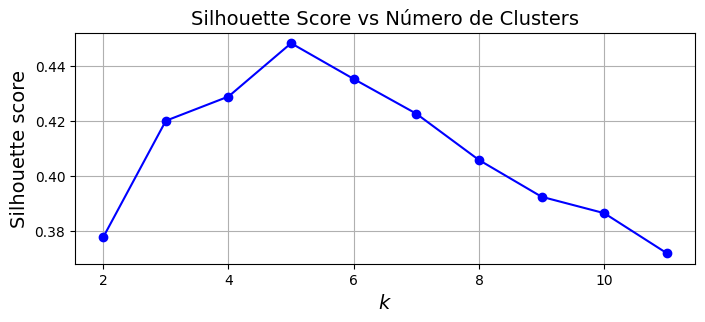

In [ ]:
max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()


### Método del Codo

Calcula la inercia para distintos valores de k.


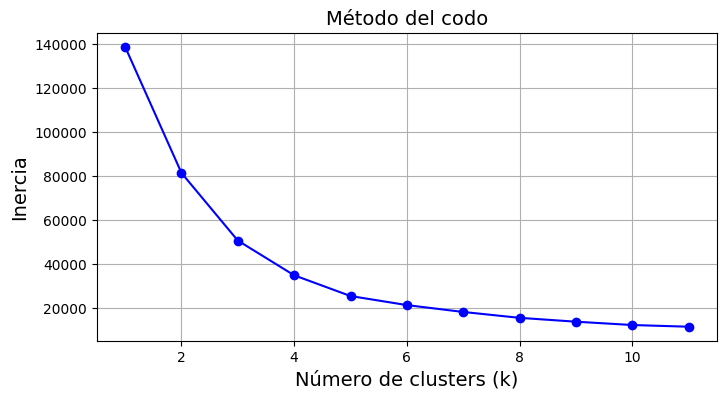

In [ ]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta.


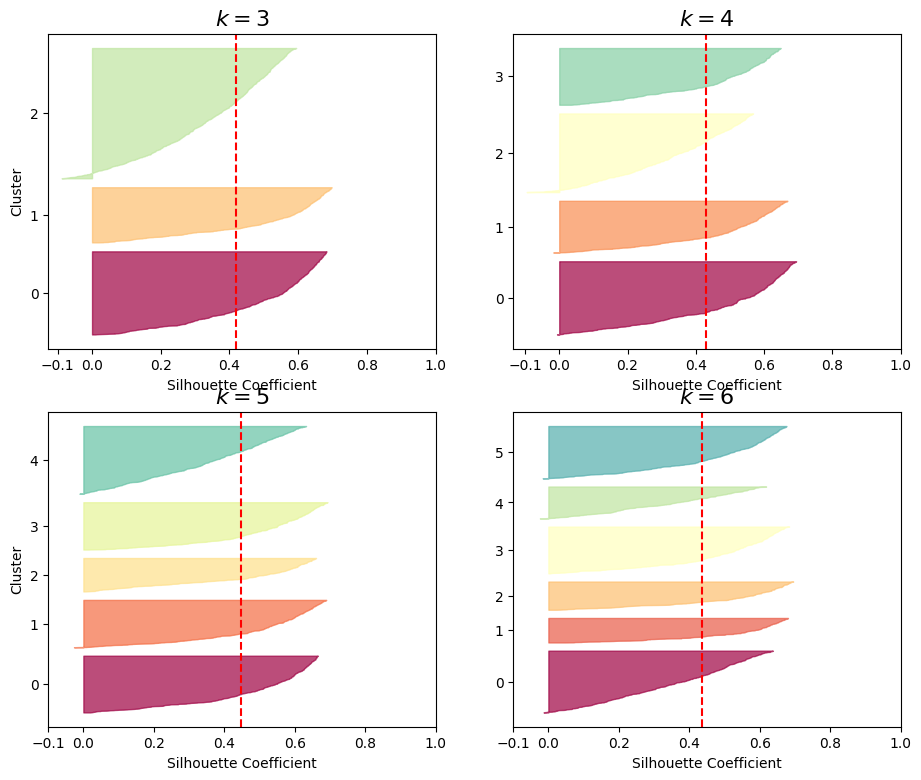

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()


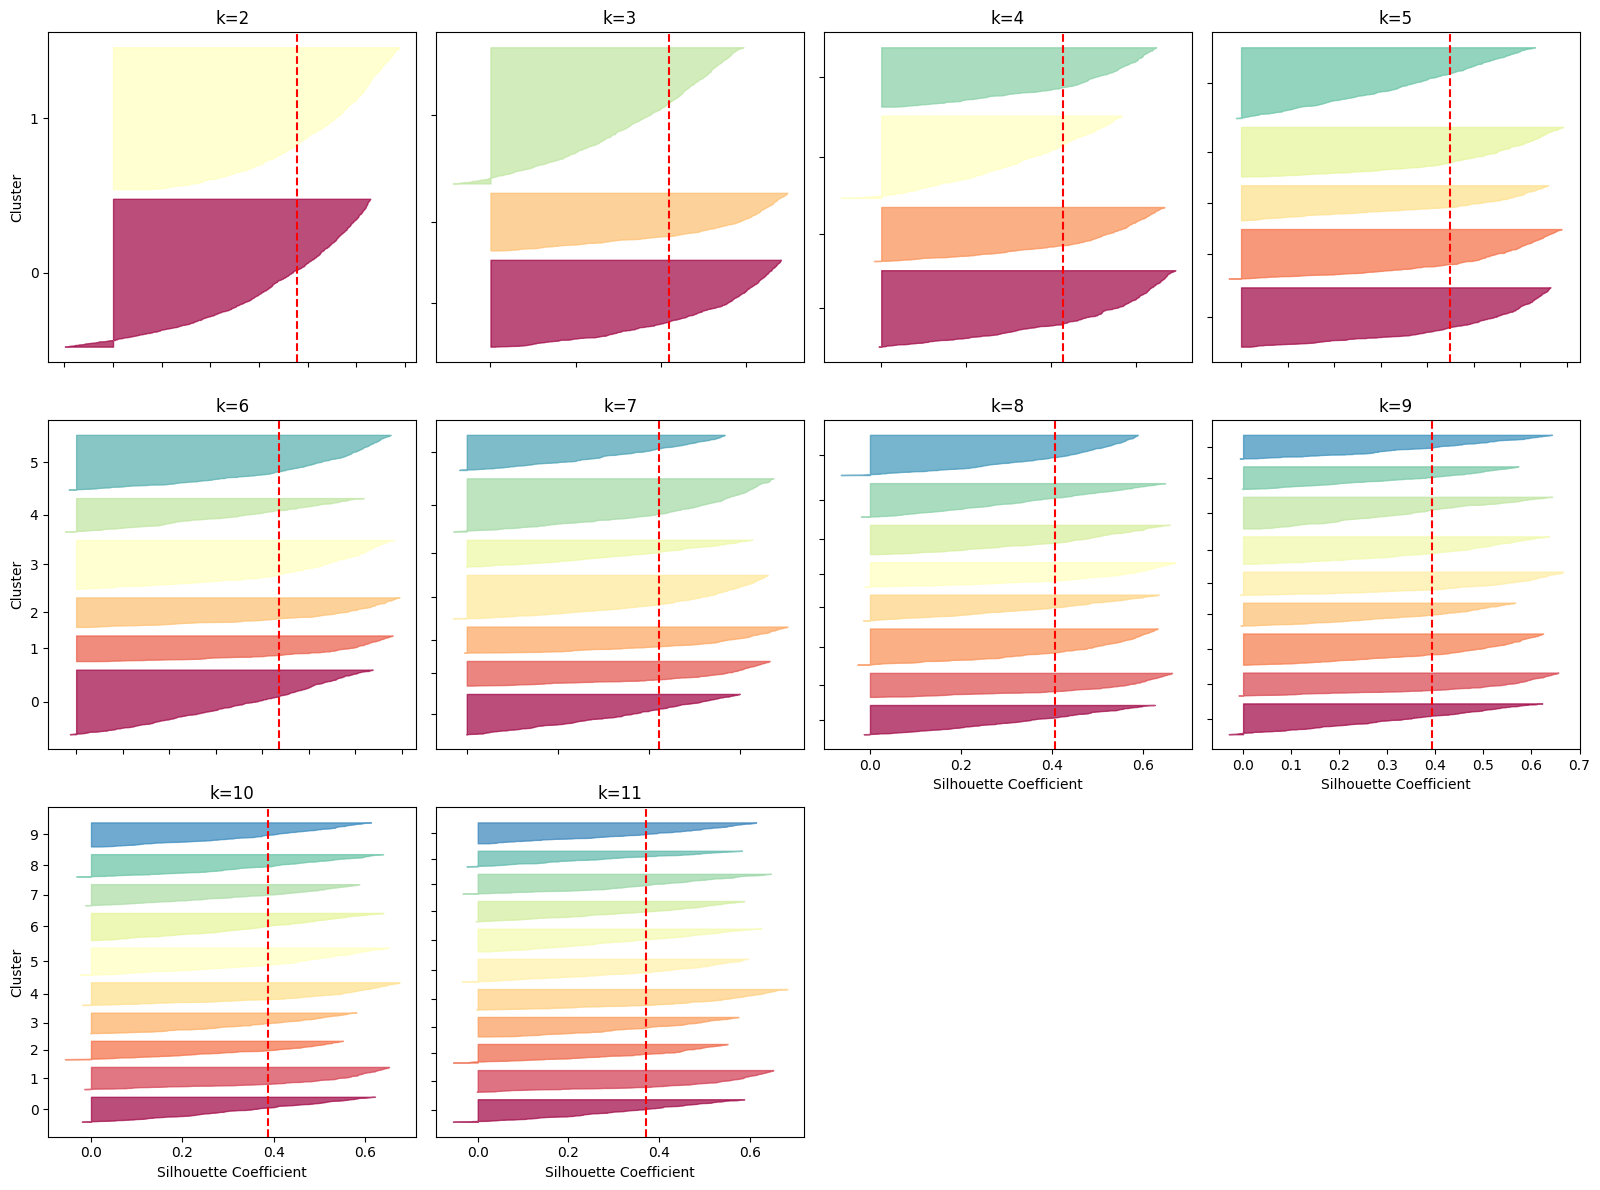

In [ ]:
import math

model_ks = list(range(2, len(kmeans_per_k) + 1))
num_plots = len(model_ks)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

plt.figure(figsize=(16, 4 * num_rows))

for plot_idx, k in enumerate(model_ks, start=1):
    plt.subplot(num_rows, num_cols, plot_idx)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(
            np.arange(pos, pos + len(coeffs)), 0, coeffs,
            facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if plot_idx % num_cols == 1:
        plt.ylabel("Cluster", fontsize=10)
    else:
        plt.tick_params(labelleft=False)

    if plot_idx > num_plots - num_cols:
        plt.xlabel("Silhouette Coefficient", fontsize=10)
    else:
        plt.tick_params(labelbottom=False)

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"k={k}", fontsize=12)

plt.tight_layout()
plt.show()


### K-Means para Aprendizaje Semi-Supervisado.

El aprendizaje semi-supervisado, también conocido como *Semi-supervised Learning*, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset **Butterfly & Moths Image Classification (100 especies)** y el algoritmo K-Means. Para comenzar, cargamos el dataset y preparamos los datos.

> **Dataset:** [Butterfly & Moths — Kaggle](https://www.kaggle.com/datasets/gpiosenka/butterfly-images40-species)  
> Más de 12 500 imágenes · 100 especies


#### 1. Carga del Dataset

Las imágenes se encuentran en una carpeta plana llamada `DATASET_UNLABELED` (todas las imágenes sin subcarpetas de clase). Cargamos todas las imágenes, las normalizamos dividiendo entre 255 y hacemos un split **80% entrenamiento / 20% test** usando `train_test_split`, igual que en el notebook de referencia.


In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ── RUTA ──────────────────────────────────────────────────────
dataset_root = Path(r"D:\7mo Semestre\SIS420 Inteligencia Artificial\Primer Parcial\Laboratorios\Laboratorio7\DATASET_UNLABELED")
# ─────────────────────────────────────────────────────────────────────────

IMG_SIZE = (64, 64)

print("Cargando imágenes desde DATASET_UNLABELED...")
images, labels = [], []

for img_path in sorted(dataset_root.iterdir()):
    if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png", ".bmp", ".webp"):
        continue
    # Formato: "train__MONARCH__hash.jpg" o "test__YELLOW SWALLOW TAIL__hash.jpg"
    # Separador: doble guion bajo "__"
    partes = img_path.stem.split("__")
    if len(partes) < 3:
        continue   # nombre inesperado, saltar
    species = partes[1].strip().upper()
    try:
        img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(species)
    except Exception:
        pass

images = np.array(images)
labels = np.array(labels)

print(f"Total imágenes cargadas: {len(images)}")
print(f"Clases únicas:           {len(np.unique(labels))}")
print(f"Ejemplo de etiquetas:    {np.unique(labels)[:5]}")

# Split 80/20
X_train_imgs, X_test_imgs, y_train_raw, y_test_raw = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# Aplanar: (N, 64, 64, 3) → (N, 12288)
X_train_flat = X_train_imgs.reshape(len(X_train_imgs), -1)
X_test_flat  = X_test_imgs.reshape(len(X_test_imgs),  -1)

# Codificar etiquetas a enteros
le = LabelEncoder()
le.fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_test  = le.transform(y_test_raw)

print(f"X_train: {X_train_flat.shape}  |  X_test: {X_test_flat.shape}")
print(f"y_train: {y_train.shape}       |  y_test:  {y_test.shape}")


Cargando imágenes desde DATASET_UNLABELED...
Total imágenes cargadas: 13573
Clases únicas:           100
Ejemplo de etiquetas:    ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO']
X_train: (10858, 12288)  |  X_test: (2715, 12288)
y_train: (10858,)       |  y_test:  (2715,)


#### 2. Reducción de Dimensionalidad con PCA

Cada imagen de 64×64×3 píxeles tiene **12 288 features**. Trabajar directamente con tantas dimensiones tiene varios problemas:

- **Maldición de la dimensionalidad:** en espacios de alta dimensión, las distancias euclidianas pierden significado — todos los puntos quedan "igual de lejos" y KMeans no puede separar bien los grupos.
- **Costo computacional:** KMeans con 12 288 features sobre miles de imágenes es muy lento.
- **Ruido:** muchos píxeles contienen información irrelevante (fondo, iluminación) que confunde al modelo.

La solución es aplicar **PCA** para comprimir cada imagen a sus componentes más informativas, eliminando el ruido y manteniendo la estructura visual importante. ¿Baja la calidad? Sí, visualmente se pierde detalle, pero matemáticamente se retiene la mayor parte de la varianza útil para clasificar.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# PCA: reducir a 150 componentes
# Estas 150 "direcciones" capturan la mayor varianza de las imágenes
pca = PCA(n_components=150, random_state=42)
X_train = pca.fit_transform(X_train_flat)
X_test  = pca.transform(X_test_flat)

varianza = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada con 150 componentes: {varianza:.1%}")
print(f"Features originales: {X_train_flat.shape[1]:,}")
print(f"Features PCA:        {X_train.shape[1]}")
print(f"Reducción:           {X_train_flat.shape[1] / X_train.shape[1]:.0f}x menos dimensiones")

# StandardScaler: escalar para que KMeans trate todas las componentes por igual
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


Varianza explicada con 150 componentes: 83.8%
Features originales: 12,288
Features PCA:        150
Reducción:           82x menos dimensiones


##### Efecto visual del PCA — ¿Qué le pasa a la imagen?

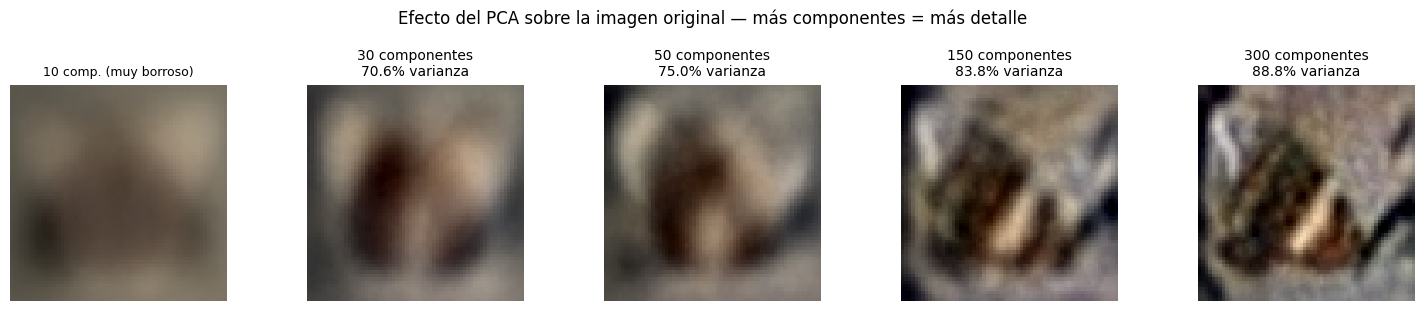

In [ ]:
# Mostrar el efecto de PCA sobre una imagen real del dataset
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
componentes = [10, 30, 50, 150, 300]

imagen_original = X_train[0]

for ax, n_comp in zip(axes, componentes):
    pca_temp = PCA(n_components=n_comp, random_state=42)
    X_temp   = pca_temp.fit_transform(X_train_flat)
    img_rec  = pca_temp.inverse_transform(X_temp[0:1])[0]
    img_rec  = img_rec.reshape(IMG_SIZE[0], IMG_SIZE[1], 3).clip(0, 1)
    var_exp  = pca_temp.explained_variance_ratio_.sum()

    ax.imshow(img_rec)
    ax.set_title(f"{n_comp} componentes\n{var_exp:.1%} varianza", fontsize=10)
    ax.axis('off')

axes[0].set_title(f"10 comp. (muy borroso)", fontsize=9)
fig.suptitle("Efecto del PCA sobre la imagen original — más componentes = más detalle",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


#### 3. Entrenamiento KMeans — Imágenes Representativas

Imagina que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos $X$ y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, **100 grupos**. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.


In [ ]:
from sklearn.cluster import KMeans

k = 160
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
X_digits_dist = kmeans.fit_transform(X_train)

print(X_digits_dist.shape)
print(X_digits_dist)


(10858, 100)
[[10.506808  11.342689   9.921551  ... 19.703505  16.214365   9.897403 ]
 [10.248993  10.895982   9.834338  ... 19.814857  16.675161  10.188928 ]
 [ 9.450387   9.617894   8.743923  ... 18.205936  15.9691     8.598306 ]
 ...
 [12.131338  12.840261  11.8541975 ... 19.482824  19.630993  12.10164  ]
 [11.461901  11.674816  10.822449  ... 19.515379  16.928524  10.702632 ]
 [ 8.121835  11.173638  10.27569   ... 19.17965   17.30259   10.309452 ]]


In [ ]:
# Imagen más cercana a cada centroide = la más "representativa" del grupo
idxs = np.argmin(X_digits_dist, axis=0)
idxs = np.clip(idxs, 0, len(X_train) - 1)
X_representative_digits = X_train[idxs]

print(X_representative_digits.shape)


(100, 150)


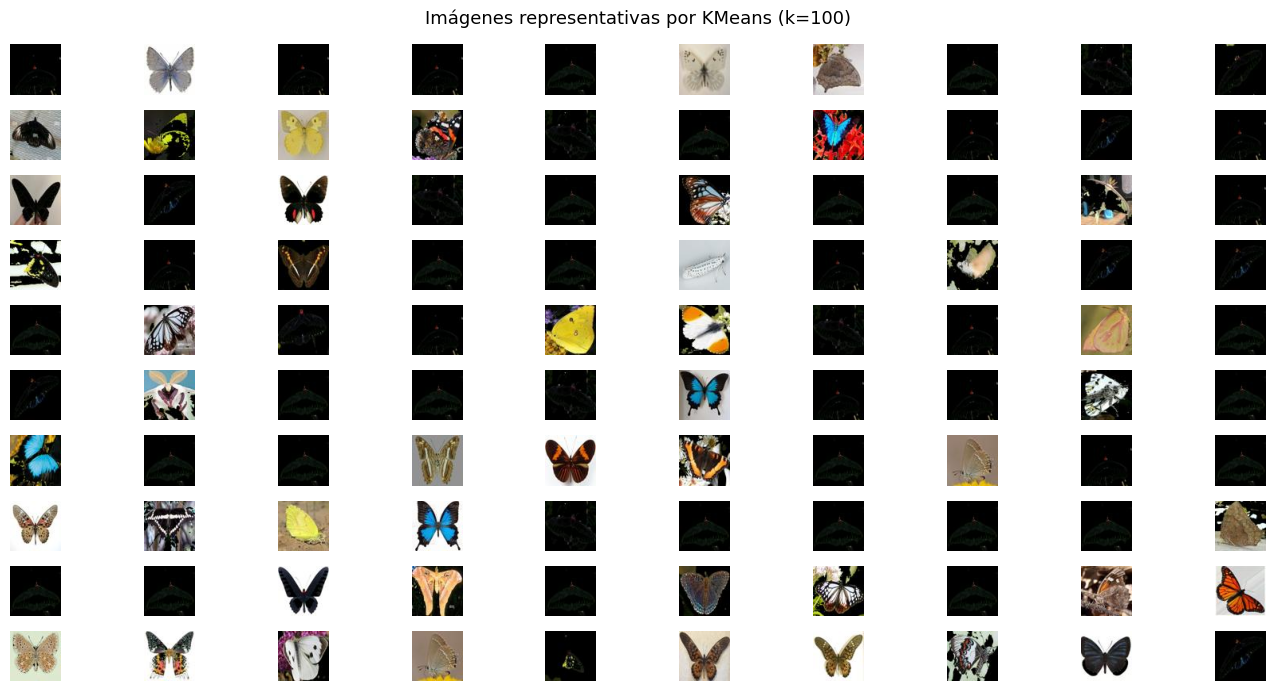

In [ ]:
# Mostrar las 100 imágenes representativas — cada una es la más cercana a su centroide
plt.figure(figsize=(14, 7))
for index, orig_idx in enumerate(idxs):
    plt.subplot(10,10,index + 1)
    plt.imshow(X_train_imgs[orig_idx])
    plt.axis('off')
plt.suptitle(f'Imágenes representativas por KMeans (k={k})', fontsize=13)
plt.tight_layout()
plt.show()


El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas ).

In [ ]:
# "Trampa": usar las etiquetas reales de los representantes
y_representative_digits = y_train[idxs]   # enteros codificados con LabelEncoder
print("Etiquetas representantes:", y_representative_digits)


Etiquetas representantes: [16 21 16 16 16 11 92 16 16 16 16 90 90 80 16 16 94 16 16 16 16 16 47 16
 16 23 16 16 57 16 20 16 54 16 16 12 16 51 16 16 16 23 16 16 90 68 16 16
 90 16 16 57 16 16 16 94 16 16 11 16 94 16 16 54 82 63 16 13 16 16  1 52
 88 94 16 16 16 16 16 92 16 16 16 50 16 76 23 16  2 64  0 58 19 13 20  1
  1 69  6 16]


#### 4. Clasificador MLP

Entrenamos un **Perceptrón Multicapa (MLP)** usando las imágenes representativas. El MLP tiene capas ocultas con activación ReLU, lo que le permite aprender relaciones no lineales entre las features — algo que la Regresión Logística no puede hacer.


In [ ]:
from sklearn.neural_network import MLPClassifier

# MLP con 2 capas ocultas: 512 → 256 neuronas
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    max_iter=5000,
    random_state=42,
    verbose=False
)
%time mlp.fit(X_representative_digits, y_representative_digits)
score_mlp_rep = mlp.score(X_test, y_test)
print(f"Score MLP (50 representantes KMeans): {score_mlp_rep:.4f}")


CPU times: total: 1.16 s
Wall time: 655 ms
Score MLP (50 representantes KMeans): 0.0372


Como puedes observar hemos obtenido una precisión habiendo anotado simplemente **50 imágenes**, pero aquellas más representativas. Entrenar el mismo modelo con 50 imágenes aleatorias nos daría peores resultados.

In [ ]:
# Comparación: 50 imágenes ALEATORIAS
idxs_random = np.random.choice(len(X_train), 500, replace=False)
mlp_random = MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu',
                            solver='adam', max_iter=500, random_state=42)
%time mlp_random.fit(X_train[idxs_random], y_train[idxs_random])
score_mlp_random = mlp_random.score(X_test, y_test)
print(f"Score MLP (50 imágenes ALEATORIAS): {score_mlp_random:.4f}")
print(f"Mejora por selección KMeans: {score_mlp_rep - score_mlp_random:+.4f}")


CPU times: total: 7.06 s
Wall time: 3.3 s
Score MLP (50 imágenes ALEATORIAS): 0.0810
Mejora por selección KMeans: -0.0438


A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los más útiles y representativos. Una vez que hemos entrenado un clasificador con las imágenes más representativas, podemos aprovecharlo para etiquetar automáticamente el resto del conjunto. Para ello, asignamos a todas las imágenes de cada grupo la misma etiqueta que le dimos a su representante.


In [ ]:
# Propagar etiquetas a TODO el set de entrenamiento
y_train_propagated = np.empty(len(X_train), dtype=int)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

print("Etiquetas propagadas a", len(y_train_propagated), "muestras")
print("Clases únicas propagadas:", len(np.unique(y_train_propagated)))


Etiquetas propagadas a 10858 muestras
Clases únicas propagadas: 30


In [ ]:
mlp3 = MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu',
                     solver='adam', max_iter=300, random_state=42)
%time mlp3.fit(X_train[:5000], y_train_propagated[:5000])
score_mlp_prop = mlp3.score(X_test, y_test)
print(f"Score MLP (etiquetas propagadas, 5000 muestras): {score_mlp_prop:.4f}")


CPU times: total: 21.8 s
Wall time: 9.82 s
Score MLP (etiquetas propagadas, 5000 muestras): 0.0258


A veces, al intentar mejorar el modelo añadiendo más datos etiquetados automáticamente, el resultado puede ser peor. Esto ocurre porque no todas las imágenes quedan bien agrupadas y se introduce ruido en el entrenamiento. Para evitarlo, podemos limitar el etiquetado solo a las muestras que estén más cerca de los representantes de cada grupo, o bien recurrir a técnicas de **Aprendizaje Activo** para seleccionar mejor qué ejemplos anotar.


### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en los que el modelo tenga más problemas — es decir, aquellos en los que el modelo tiene menor confianza en su predicción.


In [ ]:
# Calcular la confianza del modelo sobre las 10000 muestras propagadas
probas = mlp3.predict_proba(X_train[:10000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
print("Confianzas más bajas (las más inciertas):")
print(labels[sorted_ixs[:10]])


Confianzas más bajas (las más inciertas):
[0.3425488  0.38338783 0.38500282 0.4002683  0.40828153 0.4094741
 0.42499426 0.43579924 0.44322094 0.4441473 ]


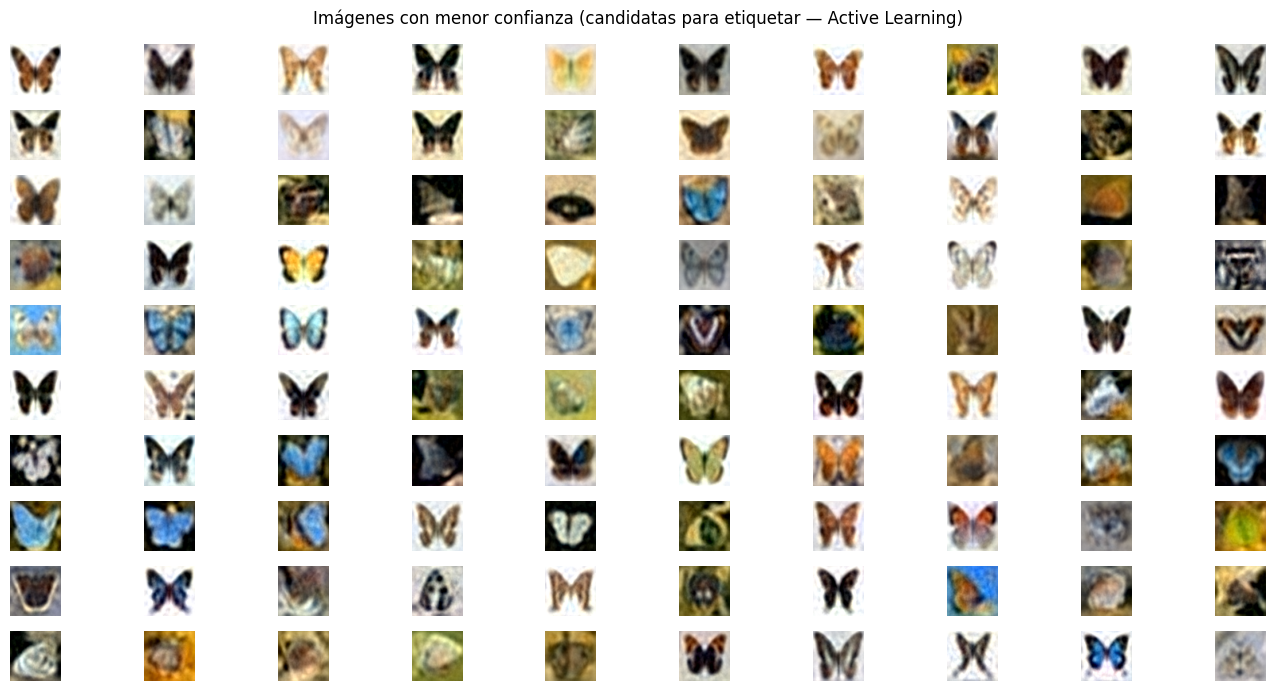

In [ ]:
# Mostrar las k imágenes con menor confianza 
X_lowest = X_train[:10000][sorted_ixs[:k]]
plt.figure(figsize=(14, 7))
for index, img in enumerate(X_lowest):
    plt.subplot(10, 10, index + 1)
    # Reconstruir imagen desde PCA+Scaler para visualizar
    img_rec = pca.inverse_transform(scaler.inverse_transform(img.reshape(1, -1)))[0]
    plt.imshow(img_rec.reshape(IMG_SIZE[0], IMG_SIZE[1], 3).clip(0, 1))
    plt.axis('off')
plt.suptitle("Imágenes con menor confianza (candidatas para etiquetar — Active Learning)",
             fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Obtener las etiquetas REALES de esas imágenes (en la práctica, las etiquetaría un humano)
y_lowest = y_train[:10000][sorted_ixs[:k]]
y_lowest


array([ 1, 43, 50, 58, 26, 58,  7, 80, 65, 46, 58, 27, 27, 58, 85, 17, 11,
       58, 99, 58, 31, 27, 18, 30, 16, 43, 31,  4, 13, 74, 38, 46, 88, 37,
       19, 43, 50, 19, 49, 52, 11, 43, 14, 58, 21, 54,  6, 75, 30, 54, 46,
        1, 47, 30, 37, 37, 47, 50, 73, 15,  4, 58,  0, 74, 15, 28, 36, 78,
       56, 83,  0,  0,  0, 46, 19, 26, 50,  3, 42, 28, 65, 62, 38, 39, 50,
       69, 46, 64,  3, 60, 56, 64, 38, 21, 40, 18, 46, 62, 94, 42])

In [ ]:
# Reemplazar las etiquetas propagadas (ruidosas) por las etiquetas reales
y_train2 = y_train_propagated[:10000].copy()
y_train2[sorted_ixs[:k]] = y_lowest


In [ ]:
mlp5 = MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu',
                     solver='adam', max_iter=300, random_state=42)
%time mlp5.fit(X_train[:10000], y_train2)
score_mlp_active = mlp5.score(X_test, y_test)
print(f"Score MLP Active Learning: {score_mlp_active:.4f}")


CPU times: total: 43.9 s
Wall time: 19 s
Score MLP Active Learning: 0.0302


Podemos repetir el proceso tantas veces como sea necesario hasta llegar a las prestaciones requeridas.

### Resumen de Resultados

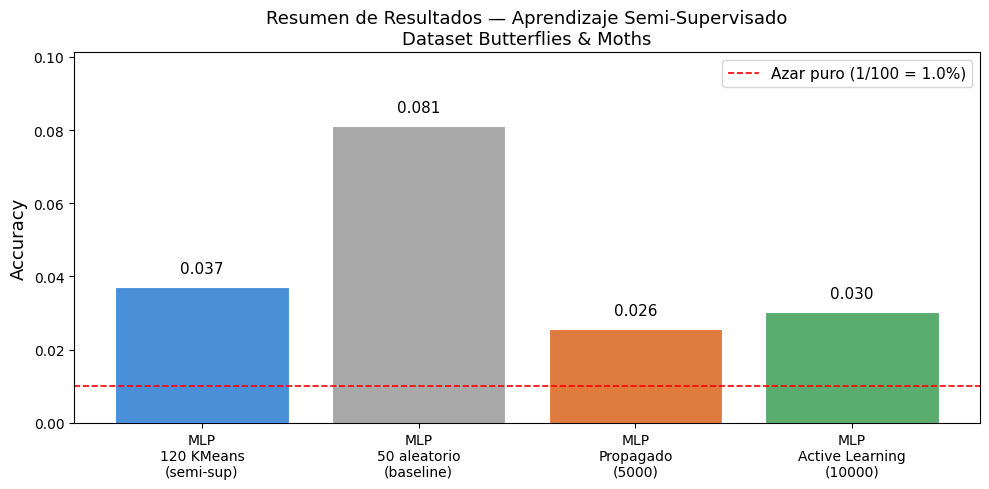

RESUMEN DE SCORES — Dataset Butterflies & Moths
  100 clases  |  Split 80/20  |  PCA 150 componentes
MLP 50 representantes KMeans (semi-sup): 0.0372
MLP 50 imágenes aleatorias   (baseline): 0.0810
MLP etiquetas propagadas     (5000):     0.0258
MLP Active Learning          (10000):     0.0302
Azar puro (1/100):                        0.0100
Mejora KMeans vs aleatorio:              -0.0438


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

etiquetas = [
    'MLP\n120 KMeans\n(semi-sup)',
    'MLP\n50 aleatorio\n(baseline)',
    'MLP\nPropagado\n(5000)',
    'MLP\nActive Learning\n(10000)'
]
scores = [score_mlp_rep, score_mlp_random, score_mlp_prop, score_mlp_active]
colores = ['#4A90D9', '#A8A8A8', '#E07B3F', '#5BAD6F']

plt.figure(figsize=(10, 5))
bars = plt.bar(etiquetas, scores, color=colores, edgecolor='white', linewidth=0.8)
for bar, sc in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{sc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='500')

n_clases = len(le.classes_)
plt.axhline(y=1/n_clases, color='red', linestyle='--', linewidth=1.2,
            label=f'Azar puro (1/{n_clases} = {1/n_clases*100:.1f}%)')
plt.ylabel("Accuracy", fontsize=13)
plt.title("Resumen de Resultados — Aprendizaje Semi-Supervisado\nDataset Butterflies & Moths",
          fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0, max(scores) * 1.25)
plt.tight_layout()
plt.show()

print("=" * 56)
print("RESUMEN DE SCORES — Dataset Butterflies & Moths")
print(f"  100 clases  |  Split 80/20  |  PCA 150 componentes")
print("=" * 56)
print(f"MLP 50 representantes KMeans (semi-sup): {score_mlp_rep:.4f}")
print(f"MLP 50 imágenes aleatorias   (baseline): {score_mlp_random:.4f}")
print(f"MLP etiquetas propagadas     (5000):     {score_mlp_prop:.4f}")
print(f"MLP Active Learning          (10000):     {score_mlp_active:.4f}")
print("=" * 56)
print(f"Azar puro (1/100):                        {1/n_clases:.4f}")
print(f"Mejora KMeans vs aleatorio:              {score_mlp_rep - score_mlp_random:+.4f}")
